# Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from ydata_profiling import ProfileReport
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import scipy.stats as stats
from scipy.linalg import inv
from scipy.spatial import distance

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.multivariate.manova import MANOVA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.preprocessing import StandardScaler

import pingouin as pg

In [3]:
import statsmodels
print(statsmodels.__version__)

0.14.0


# Laod Data

In [4]:
filename = './Results/output02.csv'
df = pd.read_csv(filename, header=0, index_col=0)
df.head()

,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_cosine,Adj_euclidean,Adj_manhattan,Verb_cosine,Verb_euclidean,Verb_manhattan,Noun_cosine,Noun_euclidean,Noun_manhattan
MID,,,,,,,,,,,,,,,,
2,193.0,1,45,3,2,5,HighIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,137.0,1,36,4,2,2,LowIOS,NaN,NaN,NaN,0.933851,0.344139,1.932724,0.882830,0.469692,2.609289
7,293.0,1,54,1,2,5,HighIOS,0.489526,0.77925,4.465907,0.826740,0.433577,2.556113,0.035336,1.129285,6.480907
8,103.0,1,36,1,2,1,LowIOS,NaN,NaN,NaN,NaN,NaN,NaN,0.397660,1.097579,6.200497
11,160.0,1,56,1,2,2,LowIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

rt                      0
self_sex                0
self_age                0
target_likedislike      0
target_sex              0
IOS_score               0
IOS_group               0
Adj_cosine            184
Adj_euclidean         184
Adj_manhattan         184
Verb_cosine           152
Verb_euclidean        152
Verb_manhattan        152
Noun_cosine           157
Noun_euclidean        157
Noun_manhattan        157
dtype: int64

# Create a Dataset for Cosine Similarity

In [6]:
# Remove some columns to create a new dataframe
df_dist = df.drop(columns=['Adj_cosine', 'Adj_euclidean',
                             'Verb_cosine', 'Verb_euclidean',
                             'Noun_cosine', 'Noun_euclidean',
                             'Noun_manhattan'])
df_dist.head()

,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_manhattan,Verb_manhattan
MID,,,,,,,,,
2,193.0,1,45,3,2,5,HighIOS,NaN,NaN
5,137.0,1,36,4,2,2,LowIOS,NaN,1.932724
7,293.0,1,54,1,2,5,HighIOS,4.465907,2.556113
8,103.0,1,36,1,2,1,LowIOS,NaN,NaN
11,160.0,1,56,1,2,2,LowIOS,NaN,NaN


# Missing Values

In [7]:
# The number of rows in the df_cosine
num_rows = len(df_dist)
# The number of rows with missing value(s)
num_rows_nan = df_dist.isnull().any(axis=1).sum()
# The percentage of rows with missing value(s)
percentage_rows_nan = num_rows_nan / num_rows * 100
# Print
print(f"Number of rows: {num_rows}")
print(f"Number of rows with missing value(s): {num_rows_nan}")
print(f"Percentage of missing data: {percentage_rows_nan}")

Number of rows: 403
Number of rows with missing value(s): 209
Percentage of missing data: 51.86104218362283


In [8]:
# Add a new columne to the df_cosine dataframe to indicate the missing values
df_dist['missing'] = df_dist.isnull().any(axis=1)

## Inspection of the Missing Values

In [9]:
# Load the data into a pandas dataframe
sentences_token_both = pd.read_csv('./Results/sentences_token_both.csv', header=0, index_col=0)
sentences_token_both.head()

,Adj_self,Verb_self,Noun_self,Adj_target,Verb_target,Noun_target
MID,,,,,,
2,[],['回答'],['梨'],[],[],[]
5,[],"['見る', '言う']",['文句'],"['悪い', 'ない']","['見かける', '見る', '言う', '見る', '許す', '反応']","['愛想', '文句']"
7,"['直ぐ', '慎重']","['許す', '聞く', '仕事', 'なる', '落とす', '進める', '飲む', '...","['人', '道', '休暇', '気', 'たま', '物', '物事']","['直ぐ', '優しい', '真面目', '勤勉', '大人しい', '好き']","['怒る', '許す', 'する']",['インドア']
8,[],[],['かし'],[],[],['ふつう']
11,"['普通', 'ない']","['いう', '守る', '排除', 'する']","['人', '社交', '他者']",[],[],[]


In [10]:
# Define a function to convert a string to a list of tokens
def string_to_tokens(string):
    # remove the square brackets
    if string == '[]':
        return []
    else:
        string = string[1:-1]
    # remove the single quotes
    string = string.replace("'", "")
    # split the string by a comma into a list of tokens
    return string.split(", ")

# Create a new dataframe with each cell containing a list of tokens
sentences_token_both = sentences_token_both.applymap(string_to_tokens)
sentences_token_both.head()

/tmp/ipykernel_8473/3674780812.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sentences_token_both = sentences_token_both.applymap(string_to_tokens)


,Adj_self,Verb_self,Noun_self,Adj_target,Verb_target,Noun_target
MID,,,,,,
2,[],[回答],[梨],[],[],[]
5,[],"[見る, 言う]",[文句],"[悪い, ない]","[見かける, 見る, 言う, 見る, 許す, 反応]","[愛想, 文句]"
7,"[直ぐ, 慎重]","[許す, 聞く, 仕事, なる, 落とす, 進める, 飲む, 嫌う]","[人, 道, 休暇, 気, たま, 物, 物事]","[直ぐ, 優しい, 真面目, 勤勉, 大人しい, 好き]","[怒る, 許す, する]",[インドア]
8,[],[],[かし],[],[],[ふつう]
11,"[普通, ない]","[いう, 守る, 排除, する]","[人, 社交, 他者]",[],[],[]


In [11]:
# Create a new dataframe with each cell containing a length of the list of tokens
sentences_token_length = sentences_token_both.applymap(len)
sentences_token_length.head()

/tmp/ipykernel_8473/2820304063.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sentences_token_length = sentences_token_both.applymap(len)


,Adj_self,Verb_self,Noun_self,Adj_target,Verb_target,Noun_target
MID,,,,,,
2,0,1,1,0,0,0
5,0,2,1,2,6,2
7,2,8,7,6,3,1
8,0,0,1,0,0,1
11,2,4,3,0,0,0


In [12]:
# Add the 'missing' column from the df_cosine dataframe with the 'sentences_token_length' dataframe
sentences_token_length['missing'] = df_dist['missing']
sentences_token_length.head()

,Adj_self,Verb_self,Noun_self,Adj_target,Verb_target,Noun_target,missing
MID,,,,,,,
2,0,1,1,0,0,0,True
5,0,2,1,2,6,2,True
7,2,8,7,6,3,1,False
8,0,0,1,0,0,1,True
11,2,4,3,0,0,0,True


In [13]:
df_ismissing = pd.DataFrame()
df_ismissing['missing'] = df_dist['missing']
df_ismissing['Adj_Verb_missing'] = (sentences_token_length['Adj_self'] * sentences_token_length['Adj_target'] * 
                                    sentences_token_length['Verb_self'] * sentences_token_length['Verb_target']) == 0
df_ismissing.head()

,missing,Adj_Verb_missing
MID,,
2,True,True
5,True,True
7,False,False
8,True,True
11,True,True


In [14]:
matrix = pd.crosstab(df_ismissing['missing'], df_ismissing['Adj_Verb_missing'])
matrix

Adj_Verb_missing,False,True
missing,,
False,194,0
True,2,207


In [15]:
sentences_token_both[(df_ismissing['missing'] == True) & (df_ismissing['Adj_Verb_missing'] == False)]

,Adj_self,Verb_self,Noun_self,Adj_target,Verb_target,Noun_target
MID,,,,,,
341,"[いい, いい]","[おもう, かんじる]",[],[いい],[かんじる],[]
550,[積極],"[する, 分かる]","[相手, 八方美人, 目, 気, 社交]",[能無し],"[発達, 使える, 媚びる, 売る]","[障害, ゴマ, スリ]"


## Evaluate the Missing Values

### Test of Independence: Missing vs. IOS group

In [16]:
# Compare the number of the occurrences of the missing values with respect to the 'IOS_group' column
crosstab_iosgroup = pd.crosstab(df_dist['missing'], df_dist['IOS_group'])
crosstab_iosgroup

IOS_group,HighIOS,LowIOS
missing,,
False,92,102
True,111,98


In [17]:
# Chi-square test of independence for the 'IOS_group' and 'missing' columns
chi2, p, dof, expected = stats.chi2_contingency(crosstab_iosgroup)
print(f"Chi2: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")

Chi2: 1.0842485666404802
p-value: 0.29774906312971233
Degrees of freedom: 1


### Test of Independence: Missing vs. IOS score

In [18]:
crosstab_iosscore = pd.crosstab(df_dist['missing'], df_dist['IOS_score'])
crosstab_iosscore

IOS_score,1,2,3,5,6,7
missing,,,,,,
False,34,36,32,28,35,29
True,31,39,28,37,37,37


In [19]:
# Chi-square test of independence for the 'IOS_score' and 'missing' columns
chi2, p, dof, expected = stats.chi2_contingency(crosstab_iosscore)
print(f"Chi2: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")

Chi2: 2.2413270362082804
p-value: 0.8148445762746928
Degrees of freedom: 5


### Test of Independence: Missing vs. Self_Sex

In [20]:
# Crosstab with the missing values and the 'self_sex' column
crosstab_self_sex = pd.crosstab(df_dist['missing'], df_dist['self_sex'])
crosstab_self_sex

self_sex,1,2,4
missing,,,
False,101,93,0
True,114,92,3


In [21]:
# Chi-square test of independence for the 'self_sex'
chi2, p, dof, expected = stats.chi2_contingency(crosstab_self_sex)
print(f"Chi2: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")

Chi2: 3.2376246386416874
p-value: 0.1981338791767277
Degrees of freedom: 2


### Mann-Whitney U test (a.k.a. Wilcoxon rank-sum test): Self_age between Missing vs. Not-Missing

In [22]:
from scipy.stats import mannwhitneyu

# Extract self_age for missing and not-missing groups
self_age_missing = df_dist[df_dist['missing']]['self_age']
self_age_not_missing = df_dist[~df_dist['missing']]['self_age']

# Perform the Mann-Whitney U test
stat, p = mannwhitneyu(self_age_missing, self_age_not_missing)

# Print the result
print(f'Mann-Whitney U test statistic: {stat}, p-value: {p}')

# Interpret the p-value
alpha = 0.05  # Typical threshold of significance
if p > alpha:
    print('No significant difference between HighIOS and LowIOS groups (fail to reject H0)')
else:
    print('Significant difference between HighIOS and LowIOS groups (reject H0)')


Mann-Whitney U test statistic: 18600.0, p-value: 0.15192495606885992
No significant difference between HighIOS and LowIOS groups (fail to reject H0)


In [23]:
# The descriptive statistics of the 'self_age' column with respect to the 'missing' column, grouped by the 'IOS_group' and 'self_sex' columns
df_dist.groupby(['missing'])['self_age'].describe()

,count,mean,std,min,25%,50%,75%,max
missing,,,,,,,,
False,194.0,48.195876,8.462828,24.0,43.0,50.0,55.0,59.0
True,209.0,46.784689,9.194823,21.0,40.0,49.0,54.0,59.0


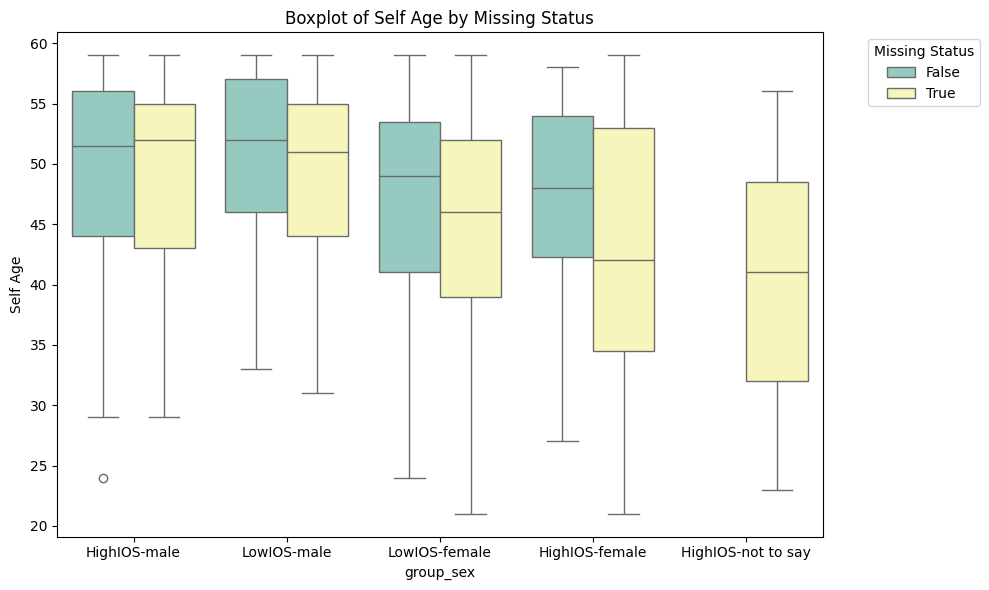

In [24]:
# Step 1: Combine Columns
df_dist['self_sex_str'] = df_dist['self_sex'].map({1: 'male', 2: 'female', 4: 'not to say'})
df_dist['group_sex'] = df_dist['IOS_group'] + '-' + df_dist['self_sex_str']
# Step 2: Create the Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='group_sex', y='self_age', hue='missing', data=df_dist, palette="Set3")
# Step 3: Customize the Plot
plt.title('Boxplot of Self Age by Missing Status')
plt.ylabel('Self Age')
plt.legend(title='Missing Status', bbox_to_anchor=(1.05, 1), loc='upper left')
# Step 4: Show the Plot
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()

### Man-Whitney U test: RT between Missing vs. Not-Missing

In [25]:
from scipy.stats import mannwhitneyu

# Assuming df is your DataFrame and it has 'group' and 'IOS_score' columns
# Extract IOS_score for HighIOS and LowIOS groups
rt_missing = df_dist[df_dist['missing']]['rt']
rt_not_missing = df_dist[~df_dist['missing']]['rt']

# Perform the Mann-Whitney U test
stat, p = mannwhitneyu(rt_missing, rt_not_missing)

# Print the result
print(f'Mann-Whitney U test statistic: {stat}, p-value: {p}')

# Interpret the p-value
alpha = 0.05  # Typical threshold of significance
if p > alpha:
    print('No significant difference between HighIOS and LowIOS groups (fail to reject H0)')
else:
    print('Significant difference between HighIOS and LowIOS groups (reject H0)')

Mann-Whitney U test statistic: 10094.5, p-value: 2.9993280318653453e-18
Significant difference between HighIOS and LowIOS groups (reject H0)


In [26]:
df_dist.groupby(['missing'])['rt'].describe()

,count,mean,std,min,25%,50%,75%,max
missing,,,,,,,,
False,194.0,1730.474227,8146.884172,89.0,280.25,440.0,740.75,89172.0
True,209.0,1921.755981,16536.664234,76.0,155.00,226.0,360.00,227706.0


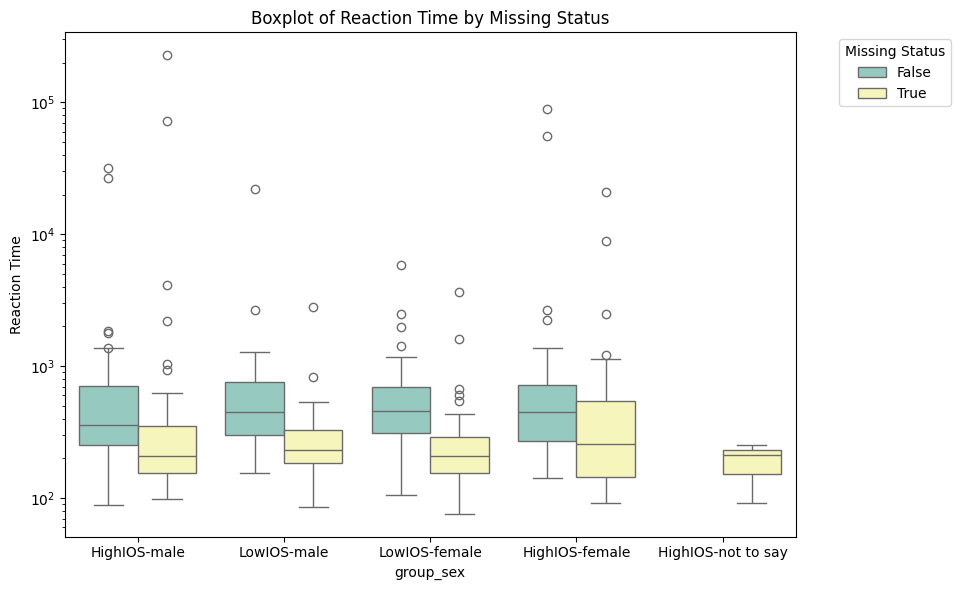

In [27]:
# Step 2: Create the Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='group_sex', y='rt', hue='missing', data=df_dist, palette="Set3")
# Step 3: Customize the Plot
plt.title('Boxplot of Reaction Time by Missing Status')
plt.ylabel('Reaction Time')
plt.legend(title='Missing Status', bbox_to_anchor=(1.05, 1), loc='upper left')
# Step 4: Show the Plot
plt.tight_layout()  # Adjust layout to make room for the legend
plt.yscale('log')
plt.show()

/tmp/ipykernel_8473/3518890372.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='missing', y='rt', data=df_dist, palette="Set3")
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


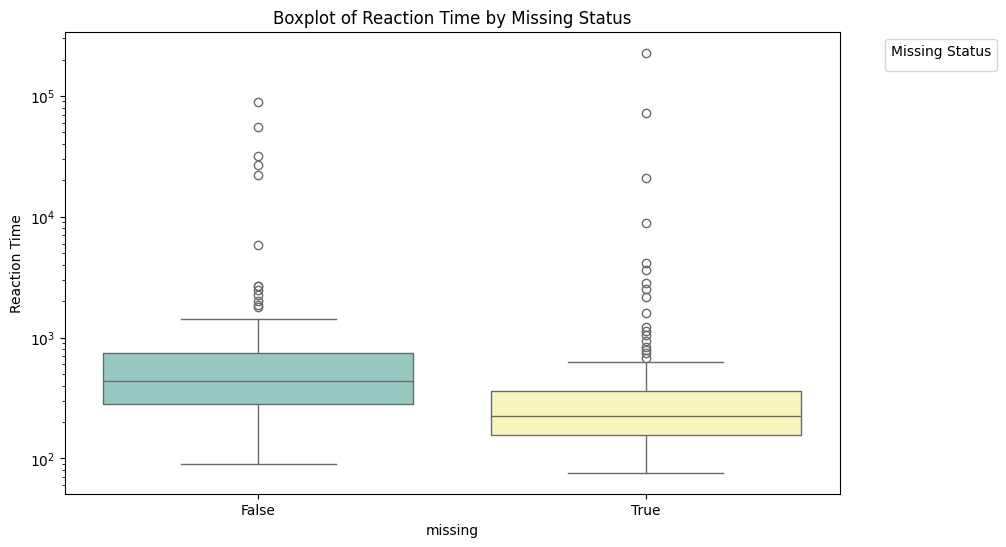

In [28]:
# Boxplot of the 'rt' column with respect to the 'missing' column
plt.figure(figsize=(10, 6))
plt.title('Boxplot of Reaction Time by Missing Status')
sns.boxplot(x='missing', y='rt', data=df_dist, palette="Set3")
plt.ylabel('Reaction Time')
plt.legend(title='Missing Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

# Data Profile

In [29]:
# Drop rows with missing value(s)
df_dist = df_dist.dropna()
print(f"The number of the ramaining observations: {len(df_dist)}")
df_dist.head()

The number of the ramaining observations: 194


,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_manhattan,Verb_manhattan,missing,self_sex_str,group_sex
MID,,,,,,,,,,,,
7,293.0,1,54,1,2,5,HighIOS,4.465907,2.556113,False,male,HighIOS-male
44,156.0,1,53,4,2,5,HighIOS,4.502885,5.296038,False,male,HighIOS-male
47,286.0,2,49,1,2,1,LowIOS,5.381318,3.338891,False,female,LowIOS-female
64,454.0,2,47,2,1,3,LowIOS,4.458152,2.131163,False,female,LowIOS-female
66,457.0,2,55,2,1,5,HighIOS,4.400890,2.585123,False,female,HighIOS-female


target_likedislike_binary  IOS_score
dislike                    1            19
                           2            18
                           3            18
                           6            15
                           5            13
                           7             8
like                       7            21
                           6            20
                           2            18
                           1            15
                           5            15
                           3            14
Name: count, dtype: int64


<Axes: xlabel='IOS_score', ylabel='count'>

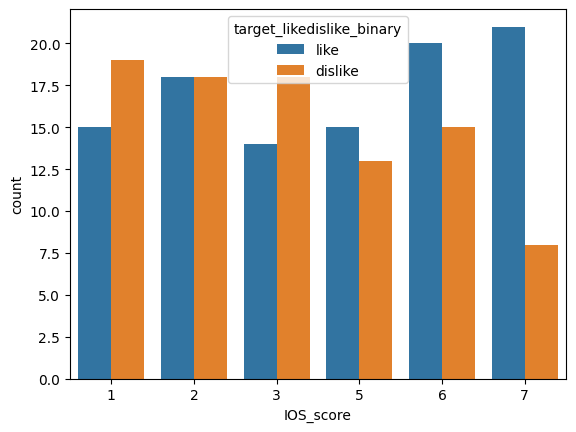

In [30]:
# Add a new column where the target_likedislike is converted to a binary variable (0: dislike, 1: like)
df_dist.loc[:, 'target_likedislike_binary'] = np.where(df_dist['target_likedislike'] < 4, 'like', 'dislike')
# The number of occurrences of each value in the IOS_group column with respect to the target_likedislike_binary
print(df_dist.groupby('target_likedislike_binary')['IOS_score'].value_counts())
# The count plot of the IOS_group column with respect to the target_likedislike_binary
sns.countplot(x='IOS_score', hue='target_likedislike_binary', data=df_dist) 

## Demographic Information

In [31]:
# The descriptive statistics of self_age with respect to the IOS_group and self_sex
df_dist.groupby(['IOS_group', 'self_sex'])['self_age'].describe()

count       mean       std   min    25%   50%   75%   max
IOS_group self_sex                                                           
HighIOS   1          50.0  48.780000  8.706765  24.0  44.00  51.5  56.0  59.0
          2          42.0  46.404762  8.593984  27.0  42.25  48.0  54.0  58.0
LowIOS    1          51.0  50.529412  7.100290  33.0  46.00  52.0  57.0  59.0
          2          51.0  46.764706  8.972376  24.0  41.00  49.0  53.5  59.0

In [32]:
# Add a new column for whether the self_sex differs from the target_sex
df_dist.loc[:, 'diff_sex'] = df_dist['self_sex'] != df_dist['target_sex']
# The count of occurrence of each value in the diff_sex with the respect of the IOS_group
df_dist.groupby('IOS_group')['diff_sex'].value_counts()

IOS_group  diff_sex
HighIOS    True        71
           False       21
LowIOS     True        65
           False       37
Name: count, dtype: int64

## Completion Time

           count         mean           std    min     25%    50%     75%  \
IOS_group                                                                   
HighIOS     92.0  2718.543478  11547.814130   89.0  258.50  408.5  711.75   
LowIOS     102.0   839.274510   2233.585379  106.0  309.75  451.5  751.50   

               max  
IOS_group           
HighIOS    89172.0  
LowIOS     22147.0  


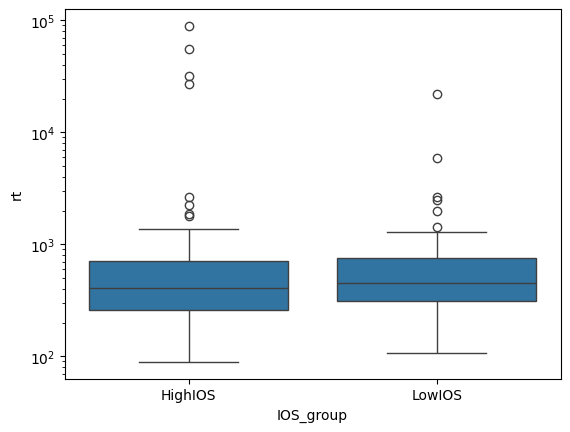

In [33]:
# The descriptive statistics of rt with respect to IOS_group
print(df_dist.groupby('IOS_group')['rt'].describe())
# The boxplot of rt with respect to IOS_group
sns.boxplot(x='IOS_group', y='rt', data=df_dist, order=['HighIOS', 'LowIOS'])
plt.yscale('log')
plt.show()

In [34]:
# Mann-Whitney U test for the rt column with respect to the IOS_group
rt_highios = df_dist[df_dist['IOS_group'] == 'HighIOS']['rt']
rt_lowios = df_dist[df_dist['IOS_group'] == 'LowIOS']['rt']
mannwhitneyu(rt_highios, rt_lowios)

MannwhitneyuResult(statistic=4088.5, pvalue=0.12254231190599578)

In [35]:
# T-test for the rt column with respect to the IOS_group
# t_stat, p = stats.ttest_ind(rt_highios, rt_lowios)
# print(f'T-test statistic: {t_stat}, p-value: {p}')
stats.ttest_ind(rt_highios, rt_lowios)

TtestResult(statistic=1.6109343479429132, pvalue=0.10883675306711944, df=192.0)

## Primary Outcomes (Similarity: Adjectives and Verbs)

In [36]:
# The descriptive statistics of the Adj_cosine column with respect to the IOS_group
df_dist.groupby('IOS_group')['Adj_manhattan'].describe()

,count,mean,std,min,25%,50%,75%,max
IOS_group,,,,,,,,
HighIOS,92.0,3.787966,1.542082,0.0,2.620330,3.542371,4.529645,7.929658
LowIOS,102.0,3.750939,1.491653,0.0,2.603602,3.482184,4.791728,7.253978


In [37]:
# The descriptive statistics of the Verb_cosine column with respect to the IOS_group
df_dist.groupby('IOS_group')['Verb_manhattan'].describe()

,count,mean,std,min,25%,50%,75%,max
IOS_group,,,,,,,,
HighIOS,92.0,2.799456,1.345854,0.00000,1.906526,2.465272,3.484385,7.085626
LowIOS,102.0,3.059493,1.562041,0.74791,1.973434,2.529506,3.899536,7.480733


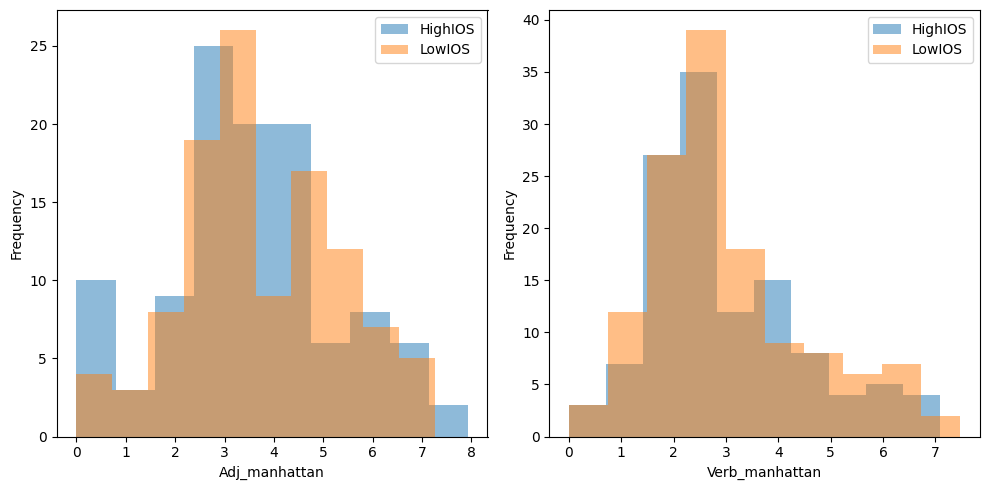

In [38]:
# Create a figure with three subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the histogram for Adj_manhattan
axes[0].hist(df['Adj_manhattan'][df['IOS_group'] == 'HighIOS'], bins=10, alpha=0.5, label='HighIOS')
axes[0].hist(df['Adj_manhattan'][df['IOS_group'] == 'LowIOS'], bins=10, alpha=0.5, label='LowIOS')
axes[0].set_xlabel('Adj_manhattan')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot the histogram for Verb_manhattan
axes[1].hist(df['Verb_manhattan'][df['IOS_group'] == 'HighIOS'], bins=10, alpha=0.5, label='HighIOS')
axes[1].hist(df['Verb_manhattan'][df['IOS_group'] == 'LowIOS'], bins=10, alpha=0.5, label='LowIOS')
axes[1].set_xlabel('Verb_manhattan')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# # Plot the histogram for Noun_cosine
# axes[2].hist(df['Noun_cosine'][df['IOS_group'] == 'HighIOS'], bins=10, alpha=0.5, label='HighIOS')
# axes[2].hist(df['Noun_cosine'][df['IOS_group'] == 'LowIOS'], bins=10, alpha=0.5, label='LowIOS')
# axes[2].set_xlabel('Noun_cosine')
# axes[2].set_ylabel('Frequency')
# axes[2].legend()

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

# Visualizing Data Distribution

## Boxplot

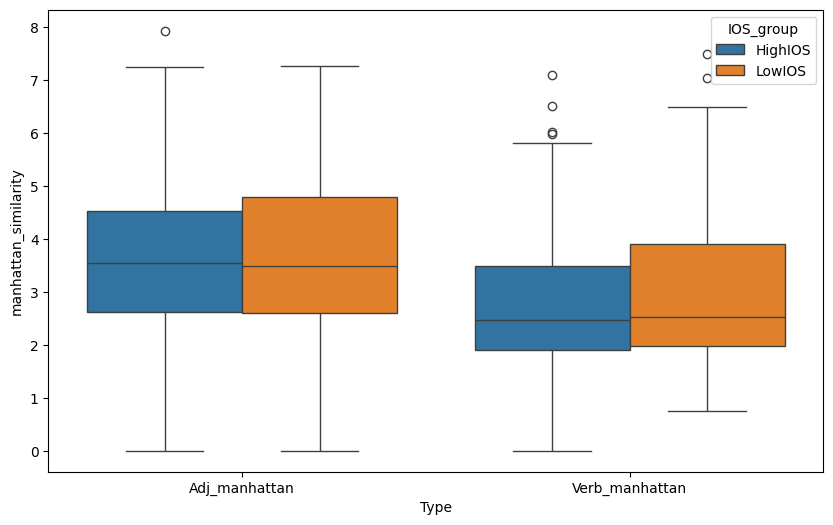

In [39]:
# melt_df = df_cosine.melt(id_vars=['IOS_group'], value_vars=['Adj_cosine', 'Verb_cosine', 'Noun_cosine'], var_name='Type', value_name='Cosine_similarity')
melt_df = df_dist.melt(id_vars=['IOS_group'], value_vars=['Adj_manhattan', 'Verb_manhattan'], var_name='Type', value_name='manhattan_similarity')
# create a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='manhattan_similarity', data=melt_df, hue='IOS_group')
#plt.ylim(0, 1.2)
plt.show()

# Assumption Check

## Adequate sample size assumption

In [40]:
# The number of samples in the HighIOS and LowIOS groups for the Adj_cosine column
print(df_dist.groupby('IOS_group')['Adj_manhattan'].count())
# The number of samples in the HighIOS and LowIOS groups for the Verb_cosine column
print(df_dist.groupby('IOS_group')['Verb_manhattan'].count())

IOS_group
HighIOS     92
LowIOS     102
Name: Adj_manhattan, dtype: int64
IOS_group
HighIOS     92
LowIOS     102
Name: Verb_manhattan, dtype: int64


The number of the observations in each cell was larger than the number of outcome variables.

## Independency of observations

In [41]:
# Replace 'HighIOS' with 1 and 'LowIOS' with 0 in the 'IOS_group' column
df_dist['IOS_group'] = df_dist['IOS_group'].replace({'HighIOS': 1, 'LowIOS': 0}).astype(int)

In [42]:
# ADJ_COSINE
md = smf.mixedlm("Adj_manhattan ~ C(1|IOS_group)", df_dist, groups=df_dist["IOS_group"])
mdf = md.fit(reml=True)
print(mdf.summary())
print("Residual Var: ", mdf.scale)
print("Group Var: ", mdf.cov_re.iloc[0, 0])
print('rho_adj:', mdf.cov_re.iloc[0, 0] / (mdf.cov_re.iloc[0, 0] + mdf.scale))

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Adj_manhattan
No. Observations: 194     Method:             REML         
No. Groups:       2       Scale:              2.2856       
Min. group size:  92      Log-Likelihood:     inf          
Max. group size:  102     Converged:          Yes          
Mean group size:  97.0                                     
-------------------------------------------------------------
              Coef.    Std.Err.   z   P>|z|   [0.025   0.975]
-------------------------------------------------------------
Intercept    -13.658                                         
Group Var      0.000                                         

Residual Var:  2.285633426676715
Group Var:  0.0
rho_adj: 0.0


/opt/conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.11/site-packages/statsmodels/r

ICC of the Adj_cosine (0.0) was much less than 0.05 (small effect: Hox, 2010)

In [43]:
# Verb_cosine
md = smf.mixedlm("Verb_manhattan ~ C(1|IOS_group)", df_dist, groups=df_dist["IOS_group"])
mdf = md.fit(reml=True)
print(mdf.summary())
print("Residual Var: ", mdf.scale)
print("Group Var: ", mdf.cov_re.iloc[0, 0])
print('rho_verb:', mdf.cov_re.iloc[0, 0] / (mdf.cov_re.iloc[0, 0] + mdf.scale))

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Verb_manhattan
No. Observations: 194     Method:             REML          
No. Groups:       2       Scale:              2.1420        
Min. group size:  92      Log-Likelihood:     -350.2095     
Max. group size:  102     Converged:          Yes           
Mean group size:  97.0                                      
-------------------------------------------------------------
               Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept      2.934     0.130  22.552  0.000   2.679   3.189
Group Var      0.012     0.033                               

Residual Var:  2.1420186157339196
Group Var:  0.011668361578099794
rho_verb: 0.005417853987612852


ICC of the Verb_cosine (0.01) was less than 0.05 (small effect: Hox, 2010)

## Univariate outlier

In [44]:
# Find extreme outliers, which are above Q3 + 3*IQR or below Q1 - 3*IQR in the Adj_manhattan column
Q1 = df_dist['Adj_manhattan'].quantile(0.25)
Q3 = df_dist['Adj_manhattan'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR
extreme_outliers = df_dist[(df_dist['Adj_manhattan'] < lower_bound) | (df_dist['Adj_manhattan'] > upper_bound)]
extreme_outliers


,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_manhattan,Verb_manhattan,missing,self_sex_str,group_sex,target_likedislike_binary,diff_sex
MID,,,,,,,,,,,,,,


There were no univariate extreme outliers in the Adj_cosine, as assessed that values above Q3 + 3IQR or below Q1 - 3IQR

In [45]:
# Find extreme outliers, which are above Q3 + 3*IQR or below Q1 - 3*IQR in the Verb_manhattan column
Q1 = df_dist['Verb_manhattan'].quantile(0.25)
Q3 = df_dist['Verb_manhattan'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR
extreme_outliers = df_dist[(df_dist['Verb_manhattan'] < lower_bound) | (df_dist['Verb_manhattan'] > upper_bound)]
extreme_outliers


,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_manhattan,Verb_manhattan,missing,self_sex_str,group_sex,target_likedislike_binary,diff_sex
MID,,,,,,,,,,,,,,


There was no univariate extreme outliers in the Verb_cosine, as assessed that values above Q3 + 3IQR or below Q1 - 3IQR

## Multivariate outliers

In [46]:
# Find extreme multivariate outliers using Mahalanobis distance
# The columns to be used for the Mahalanobis distance: Adj_manhattan and Verb_manhattan
X = df_dist[['Adj_manhattan', 'Verb_manhattan']]
# The mean of the columns
mean = X.mean()
# The covariance matrix of the columns
cov = X.cov()
# The inverse of the covariance matrix
inv_cov = inv(cov)
# The Mahalanobis distance
mahalanobis = [distance.mahalanobis(row, mean, inv_cov) for row in X.itertuples(index=False)]
# The threshold for the Mahalanobis distance
threshold = stats.chi2.ppf(0.999, df=2)
# The multivariate outliers
multivariate_outliers = df_dist[mahalanobis > threshold]
multivariate_outliers

,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_manhattan,Verb_manhattan,missing,self_sex_str,group_sex,target_likedislike_binary,diff_sex
MID,,,,,,,,,,,,,,


There were no multivariate extreme outliers in the data, as assessed by Mahalanobis distance (p > 0.001)

## Univariate Normality

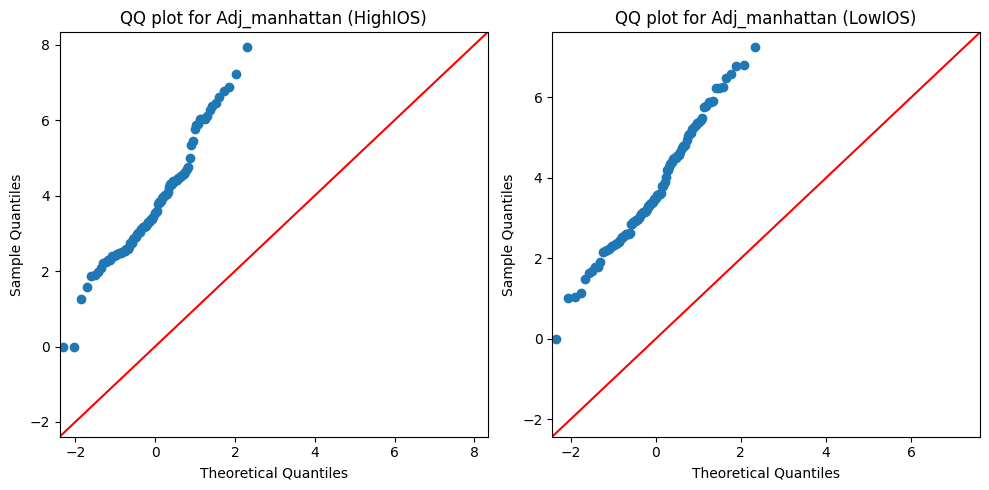

In [47]:
# QQ plot for the Adj_manhattan column with respect to the IOS_group
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sm.qqplot(df_dist[df_dist['IOS_group'] == 1]['Adj_manhattan'], line='45', ax=axs[0])
axs[0].set_title('QQ plot for Adj_manhattan (HighIOS)')
sm.qqplot(df_dist[df_dist['IOS_group'] == 0]['Adj_manhattan'], line='45', ax=axs[1])
axs[1].set_title('QQ plot for Adj_manhattan (LowIOS)')
plt.tight_layout()
plt.show()

All the points did not fell along the reference line for each group. So we cannot assumy normality of the Adj_cosine distribution.

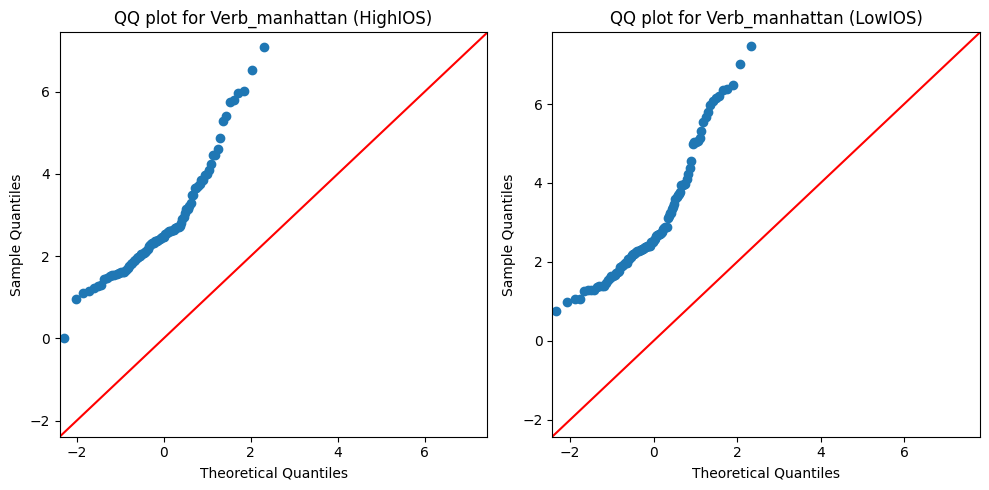

In [48]:
# QQ plot for the Verb_manhattan column with respect to the IOS_group
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sm.qqplot(df_dist[df_dist['IOS_group'] == 1]['Verb_manhattan'], line='45', ax=axs[0])
axs[0].set_title('QQ plot for Verb_manhattan (HighIOS)')
sm.qqplot(df_dist[df_dist['IOS_group'] == 0]['Verb_manhattan'], line='45', ax=axs[1])
axs[1].set_title('QQ plot for Verb_manhattan (LowIOS)')
plt.tight_layout()
plt.show()

All the points did not fell along the reference line for each group. So we cannot assumy normality of the Verb_cosine distribution.
Although the univariate normality assumptions were not met, MANOVA was performed since it is fairly robust to deviations from normality.

In [49]:
# Shapiro-Wilk test for the Adj_cosine column with respect to the IOS_group
# When the sample size is greater than 50, the Shapiro-Wilk test is not reliable
shapiro_adj = df_dist.groupby('IOS_group')['Adj_manhattan'].apply(lambda x: stats.shapiro(x))
shapiro_adj # W-statistic, p-value

IOS_group
0     (0.9849039316177368, 0.29949262738227844)
1    (0.9710137248039246, 0.038049835711717606)
Name: Adj_manhattan, dtype: object

In [50]:
# Shapiro-Wilk test for the Verb_cosine column with respect to the IOS_group
# When the sample size is greater than 50, the Shapiro-Wilk test is not reliable
shapiro_adj = df_dist.groupby('IOS_group')['Verb_manhattan'].apply(lambda x: stats.shapiro(x))
shapiro_adj # W-statistic, p-value

IOS_group
0    (0.9041554927825928, 1.8238279153592885e-06)
1    (0.9137720465660095, 1.4504114915325772e-05)
Name: Verb_manhattan, dtype: object

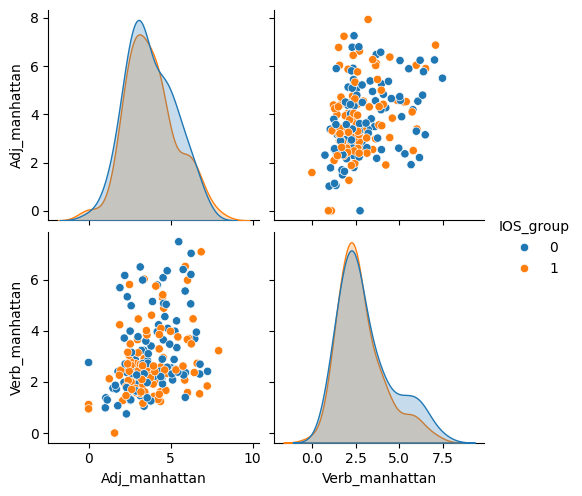

In [51]:
# Assume df_manhattan is your DataFrame and it has columns 'Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan', and 'IOS_group'
# sns.pairplot(df_manhattan, vars=['Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan'], hue='IOS_group')
# Assume df_manhattan is your DataFrame and it has columns 'Adj_manhattan', 'Verb_manhattan',  and 'IOS_group'
sns.pairplot(df_dist, vars=['Adj_manhattan', 'Verb_manhattan'], hue='IOS_group')
plt.show()

## Multivariate Normality

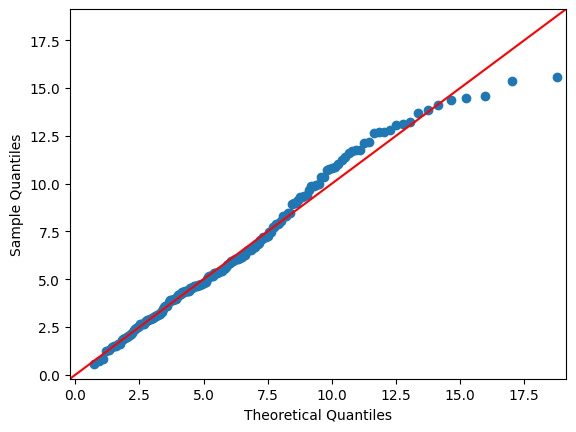

In [52]:
# Create a Q-Q plot for multivariate normality by using Mahalanobis distance,
# which measures distance between a point and a distribution
 
# Assume df_cosine is your DataFrame and it has columns 'Adj_cosine', 'Verb_cosine', and 'Noun_cosine'
# X = df_cosine[['Adj_cosine', 'Verb_cosine', 'Noun_cosine']].values
# X = df_cosine[['Adj_cosine', 'Verb_cosine']].values

# Standardize the data
# X_std = StandardScaler().fit_transform(X)

# Calculate the Mahalanobis distance
# mahalanobis = np.sqrt((X_std**2).sum(axis=1))

# # Calculate the mean of the data
# mean = np.mean(X, axis=0)
# 
# # Calculate the covariance matrix
# cov = np.cov(X, rowvar=False)
# 
# # Calculate the inverse of the covariance matrix
# inv_cov = inv(cov)
# 
# # Calculate the Mahalanobis distance
# mahalanobis = np.array([distance.mahalanobis(x, mean, inv_cov) for x in X])

# Create Q-Q plot
sm.qqplot(np.array(mahalanobis), stats.chi2, distargs=(2,), line='45', fit=True) 
plt.show()

All the points fall approximately along the reference line. So multivariate normality can be assumed.

In [53]:
# The Shapiro-Wilk test to tell if a random sample comes from a normal distribution.
# The null hypothesis of the test is that the data are normally distributed.
# 
# The Shapiro-Wilk test is typically used to test the normality of univariate data.
# For multivariate data, you might want to consider using a multivariate normality test, such as the Henze-Zirkler's multivariate normality test provided by the `pingouin` package.
# However, if you still want to apply the Shapiro-Wilk test to each variable in your multivariate data, you can do so by iterating over the columns of your DataFrame. Here's how you can do it:

# Assume df_manhattan is your DataFrame and it has columns 'Adj_manhattan', 'Verb_manhattan', and 'Noun_manhattan'
# variables = ['Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan']
variables = ['Adj_manhattan', 'Verb_manhattan']

for var in variables:
    shapiro_test = stats.shapiro(df_dist[var])
    print(f"Shapiro test for {var}: statistic={shapiro_test.statistic}, p-value={shapiro_test.pvalue}")

Shapiro test for Adj_manhattan: statistic=0.9818977117538452, p-value=0.01316034235060215
Shapiro test for Verb_manhattan: statistic=0.9076303243637085, p-value=1.2194275589294534e-09


In [54]:
# The Henze-Zirkler's multivariate normality test

# Assume df_manhattan is your DataFrame and it has columns 'Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan'
# X = df_manhattan[['Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan']]
X = df_dist[['Adj_manhattan', 'Verb_manhattan']]

# Perform multivariate normality test
result = pg.multivariate_normality(X)
print(result)

HZResults(hz=4.607114823981078, pval=2.0690680519910465e-10, normal=False)


### Exclude Outliers

In [55]:
# Find the outliers using the Mahalanobis distance
mahalanobis = np.array(mahalanobis)
outliers = mahalanobis > np.percentile(mahalanobis, 90) # compute the q-th percentile of the data along the specified axis
print(f"The number of outliers: {outliers.sum()}")
print(f"The indices of the outliers: {np.where(outliers)}")

The number of outliers: 20
The indices of the outliers: (array([  8,  13,  16,  20,  30,  32,  37,  51,  54,  59,  71,  78,  89,
        99, 113, 117, 118, 143, 164, 176]),)


In [56]:
# Access to the outliers
df_cosine_outliers = df_dist[outliers]
df_cosine_outliers.head(10)

,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_manhattan,Verb_manhattan,missing,self_sex_str,group_sex,target_likedislike_binary,diff_sex
MID,,,,,,,,,,,,,,
109,291.0,2,52,1,2,6,1,0.000000,1.115141,False,female,HighIOS-female,like,False
143,147.0,2,27,1,1,6,1,5.895123,6.514698,False,female,HighIOS-female,like,True
161,670.0,2,45,1,1,3,0,5.766220,6.392687,False,female,LowIOS-female,like,True
192,439.0,1,57,2,2,5,1,2.495026,5.806540,False,male,HighIOS-male,like,True
231,156.0,1,50,3,1,2,0,1.911437,5.682882,False,male,LowIOS-male,like,False
235,714.0,2,58,6,1,1,0,2.205842,6.162239,False,female,LowIOS-female,dislike,True
254,275.0,1,49,1,2,7,1,3.387443,6.017167,False,male,HighIOS-male,like,True
311,306.0,2,25,3,2,1,0,0.000000,2.758248,False,female,LowIOS-female,like,False
319,280.0,2,51,2,2,2,0,3.148717,6.494010,False,female,LowIOS-female,like,False


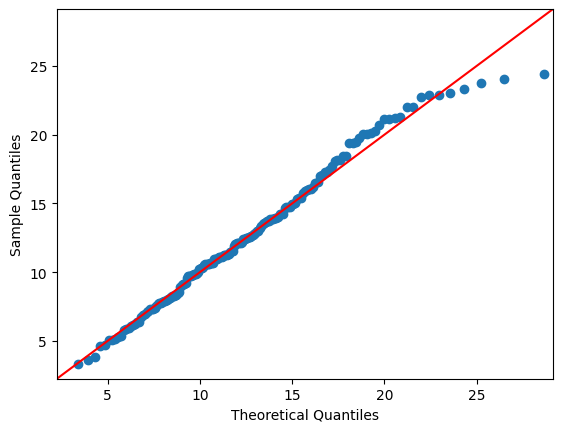

In [57]:
# Create Q-Q plot without outliers
sm.qqplot(mahalanobis[~outliers], stats.chi2, distargs=(2,), line='45', fit=True) 
plt.show()

In [58]:
# The Henze-Zirkler's multivariate normality test with outliers removed
# Data without outliers
X_norm = df_dist[['Adj_manhattan', 'Verb_manhattan']][~outliers]
# Perform multivariate normality test
result = pg.multivariate_normality(X_norm)
print(result)

HZResults(hz=2.984840333577272, pval=4.727428843063651e-07, normal=False)


## Multicollinearity

In [59]:
# Pairwise Pearson correlation between the Adj_eucidean and Verb_eucidean columns
df_dist[['Adj_manhattan', 'Verb_manhattan']].corr()

,Adj_manhattan,Verb_manhattan
Adj_manhattan,1.000000,0.339183
Verb_manhattan,0.339183,1.000000


In [60]:
# Significance of the correlation coefficient
# The number of observations
n = len(df_dist)
# The correlation coefficient
r = df_dist['Adj_manhattan'].corr(df_dist['Verb_manhattan'])
# The degrees of freedom
df = n - 2
# The t-statistic
t = r * np.sqrt(df / (1 - r**2))
# The p-value
p = 2 * (1 - stats.t.cdf(t, df))
# Result
print(f"There was no multicollinearity, as assessed by the Pearson correlation coefficient (r = {r}, t = {t}, df = {df}, p = {p}).")

There was no multicollinearity, as assessed by the Pearson correlation coefficient (r = 0.3391832022390338, t = 4.9960228585820605, df = 192, p = 1.3119643398340486e-06).


## Linearity between all the outcomes for each group

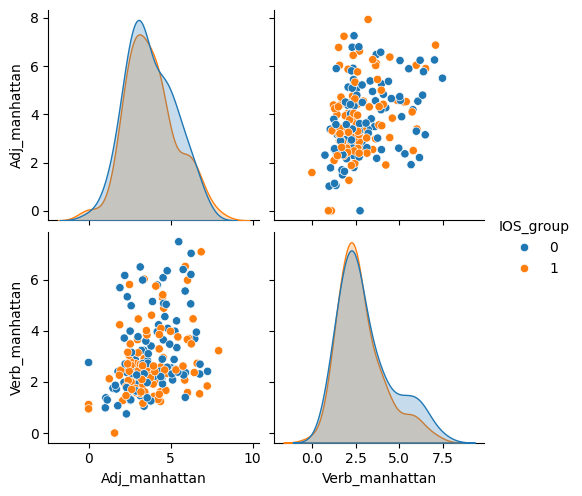

In [61]:
# Pairplots with the correlation coefficient for the HighIOS and LowIOS groups
sns.pairplot(df_dist, vars=['Adj_manhattan', 'Verb_manhattan'], hue='IOS_group')
plt.show()

In [62]:
# Correlation matrix for Adj_manhattan, Verb_manhattan, and Noun_manhattan of HighIOS and LowIOS
df_dist.groupby('IOS_group')[['Adj_manhattan', 'Verb_manhattan']].corr()

Adj_manhattan  Verb_manhattan
IOS_group                                              
0         Adj_manhattan        1.000000        0.352724
          Verb_manhattan       0.352724        1.000000
1         Adj_manhattan        1.000000        0.330996
          Verb_manhattan       0.330996        1.000000

In [63]:
# Statistical test for the correlation between Adj_manhattan and Verb_manhattan for the HighIOS and LowIOS groups, respectively
# HighIOS
r_highios = df_dist[df_dist['IOS_group'] == 1]['Adj_manhattan'].corr(df_dist[df_dist['IOS_group'] == 1]['Verb_manhattan'])
# Test
t_stat, p = stats.ttest_ind(df_dist[df_dist['IOS_group'] == 1]['Adj_manhattan'], df_dist[df_dist['IOS_group'] == 1]['Verb_manhattan'])
print(f'HighIOS: r={r_highios}, t={t_stat}, p={p}')
# LowIOS
r_lowios = df_dist[df_dist['IOS_group'] == 0]['Adj_manhattan'].corr(df_dist[df_dist['IOS_group'] == 0]['Verb_manhattan'])
# Test
t_stat, p = stats.ttest_ind(df_dist[df_dist['IOS_group'] == 0]['Adj_manhattan'], df_dist[df_dist['IOS_group'] == 0]['Verb_manhattan'])
print(f'LowIOS: r={r_lowios}, t={t_stat}, p={p}')


HighIOS: r=0.3309964446395443, t=4.632356622964714, p=6.866951298008571e-06
LowIOS: r=0.35272383599700413, t=3.2331995743793525, p=0.0014297792416831663


There was a linear relationship between the Adj_cosine and Verb_cosine in each IOS group, as assessed by scatter plot (r=0.16 in the High IOS; r=0.34 in the Low IOS).

## Homogeneity of variance for each variable

In [64]:
# Levene's test for the equality of variances between the HighIOS and LowIOS groups for the Adj_manhattan column
stats.levene(df_dist[df_dist['IOS_group'] == 1]['Adj_manhattan'], df_dist[df_dist['IOS_group'] == 0]['Adj_manhattan'])

LeveneResult(statistic=0.00047266262899285237, pvalue=0.9826772905942568)

In [65]:
# Levene's test for the equality of variances between the HighIOS and LowIOS groups for the Verb_manhattan column
stats.levene(df_dist[df_dist['IOS_group'] == 1]['Verb_manhattan'], df_dist[df_dist['IOS_group'] == 0]['Verb_manhattan'])

LeveneResult(statistic=1.7054800220187871, pvalue=0.19313534048434897)

The Levene's test for each of the outcome variables was not significant, so there was equal variances between groups in each outcome variables.

## Homogeneity of covariance matrices

In [66]:
# The Box's M test to examine the homogeneity of covariance matrices across groups.
# The null hypothesis of the test is that the covariance matrices are equal across groups.

# Perform Box's M test
# result = pg.multivariate.box_m(data=df_manhattan, dvs=['Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan'], group='IOS_group')
result = pg.multivariate.box_m(data=df_dist, dvs=['Adj_manhattan', 'Verb_manhattan'], group='IOS_group', alpha=0.001)
result

,Chi2,df,pval,equal_cov
box,2.333129,3.0,0.506204,True


The Box's M test revealed the homogeneity of the variance-covariance matrices.

# MANOVA

In [67]:
# MANOVA for Adj_manhattan, Verb_manhattan, Noun_manhattan
# maov_manhattan = MANOVA.from_formula('Adj_manhattan + Verb_manhattan + Noun_manhattan ~ IOS_group', data=df_manhattan[['IOS_group', 'Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan']])
maov_manhattan = MANOVA.from_formula('Adj_manhattan + Verb_manhattan ~ IOS_group', data=df_dist[['IOS_group', 'Adj_manhattan', 'Verb_manhattan']])
print(maov_manhattan.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.1928 2.0000 191.0000 399.7148 0.0000
         Pillai's trace 0.8072 2.0000 191.0000 399.7148 0.0000
 Hotelling-Lawley trace 4.1855 2.0000 191.0000 399.7148 0.0000
    Roy's greatest root 4.1855 2.0000 191.0000 399.7148 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
        IOS_group        Value  Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
           Wilks' lambda 0.9901 2.0000 191.0000  0.9569 0.3859
          Pillai's trace 0.0099 2.0000 191.0000  0.9569 0.3859
  Hotelling

In [68]:
maov_manhattan.mv_test().results

{'Intercept': {'stat':                            Value Num DF Den DF     F Value Pr > F
  Wilks' lambda           0.192846      2  191.0  399.714776    0.0
  Pillai's trace          0.807154    2.0  191.0  399.714776    0.0
  Hotelling-Lawley trace  4.185495      2  191.0  399.714776    0.0
  Roy's greatest root     4.185495      2    191  399.714776    0.0,
  'contrast_L': array([[1., 0.]]),
  'transform_M': array([[1., 0.],
         [0., 1.]]),
  'constant_C': array([[0., 0.]]),
  'E': array([[441.12725135, 145.52026754],
         [145.52026754, 411.26759599]]),
  'H': array([[1435.09321634, 1170.54892178],
         [1170.54892178,  954.77057704]])},
 'IOS_group': {'stat':                            Value Num DF Den DF   F Value   Pr > F
  Wilks' lambda           0.990079      2  191.0  0.956914  0.38591
  Pillai's trace          0.009921    2.0  191.0  0.956914  0.38591
  Hotelling-Lawley trace   0.01002      2  191.0  0.956914  0.38591
  Roy's greatest root      0.01002      2    

There was no significant difference between the High IOS and the Low IOS groups on the combined dependent variables (Wilk's Lambda = 0.987, df1=2, df2=191, F=1.23, p=0.29)